<a href="https://colab.research.google.com/github/SeladaKeju/pengolahan-citra/blob/main/Jobsheet4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## **JOBSHEET 04: SEGMENTASI GAMBAR**
**Nama:** Rizqi Aditya Pratama | **NIM:** 33423321 | **Kelas:** IK-3D

---

## **Praktikum 1 - Thresholding Global dan Otsu**

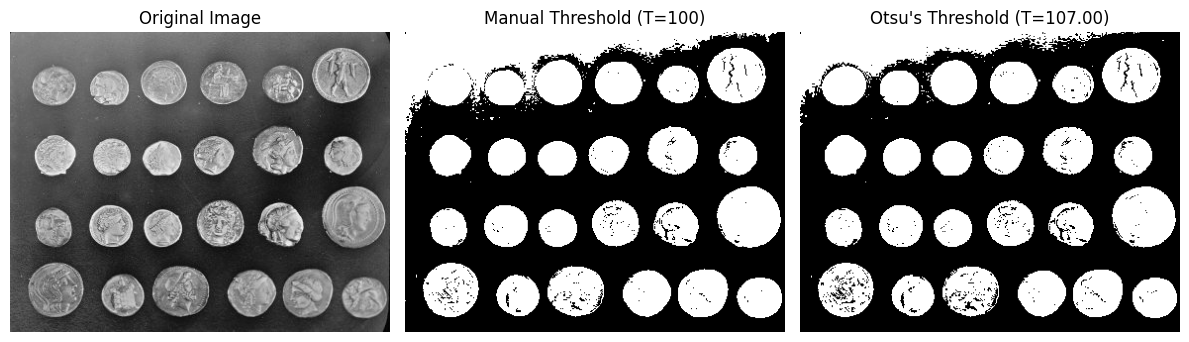

Nilai threshold Otsu yang ditemukan: 107


In [ ]:
import matplotlib.pyplot as plt
from skimage import data, filters, img_as_ubyte
from skimage.color import rgb2gray

# 1. Memuat citra (contoh: coins)
image_coins = data.coins()  # Citra sudah grayscale

# 2. Thresholding Global (manual)
# Tentukan nilai ambang manual, misal 100
thresh_manual = 100
binary_manual = image_coins > thresh_manual

# 3. Thresholding Otsu
thresh_otsu = filters.threshold_otsu(image_coins)
binary_otsu = image_coins > thresh_otsu

# 4. Visualisasi Hasil
fig, axes = plt.subplots(ncols=3, figsize=(12, 4))
ax = axes.ravel()

ax[0].imshow(image_coins, cmap=plt.cm.gray)
ax[0].set_title('Original Image')
ax[0].axis('off')

ax[1].imshow(binary_manual, cmap=plt.cm.gray)
ax[1].set_title(f'Manual Threshold (T={thresh_manual})')
ax[1].axis('off')

ax[2].imshow(binary_otsu, cmap=plt.cm.gray)
ax[2].set_title(f"Otsu's Threshold (T={thresh_otsu:.2f})")
ax[2].axis('off')

plt.tight_layout()
plt.show()

# Menampilkan nilai threshold Otsu
print(f"Nilai threshold Otsu yang ditemukan: {thresh_otsu}")

## **Praktikum 2 - Region Growing (Flood Fill)**

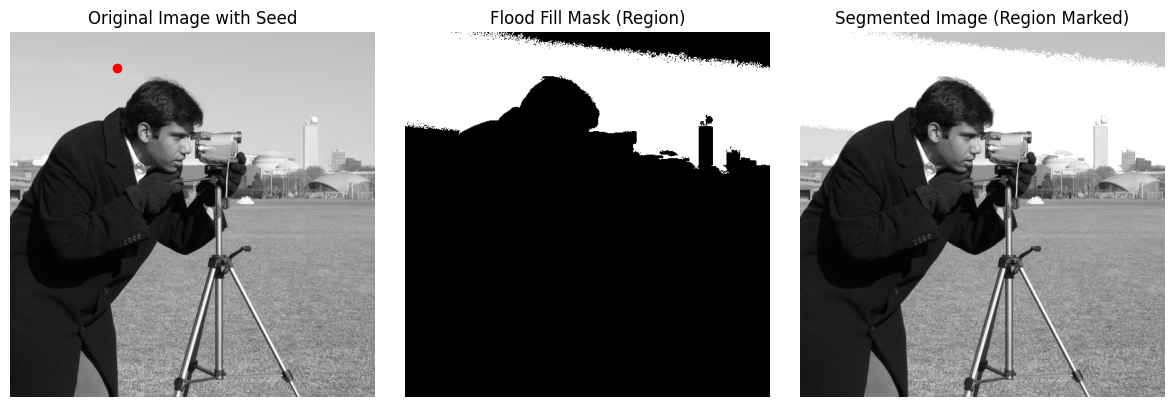

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data, segmentation, color

# 1. Memuat citra (contoh: camera)
image_camera = data.camera()

# 2. Tentukan titik 'seed' (benih)
# Misal, kita pilih titik di area langit
seed_point = (50, 150)

# 3. Terapkan algoritma flood fill
# 'tolerance' menentukan perbedaan intensitas
flood_mask = segmentation.flood(image_camera, seed_point, tolerance=10)

# 4. Buat citra tersegmentasi
segmented_image = np.copy(image_camera)
segmented_image[flood_mask] = 255

# 5. Visualisasi Hasil
fig, axes = plt.subplots(ncols=3, figsize=(12, 4))
ax = axes.ravel()

ax[0].imshow(image_camera, cmap=plt.cm.gray)
ax[0].plot(seed_point[1], seed_point[0], 'ro')
ax[0].set_title('Original Image with Seed')
ax[0].axis('off')

ax[1].imshow(flood_mask, cmap=plt.cm.gray)
ax[1].set_title('Flood Fill Mask (Region)')
ax[1].axis('off')

ax[2].imshow(segmented_image, cmap=plt.cm.gray)
ax[2].set_title('Segmented Image (Region Marked)')
ax[2].axis('off')

plt.tight_layout()
plt.show()

## **Praktikum 3 - K-Means Clustering**

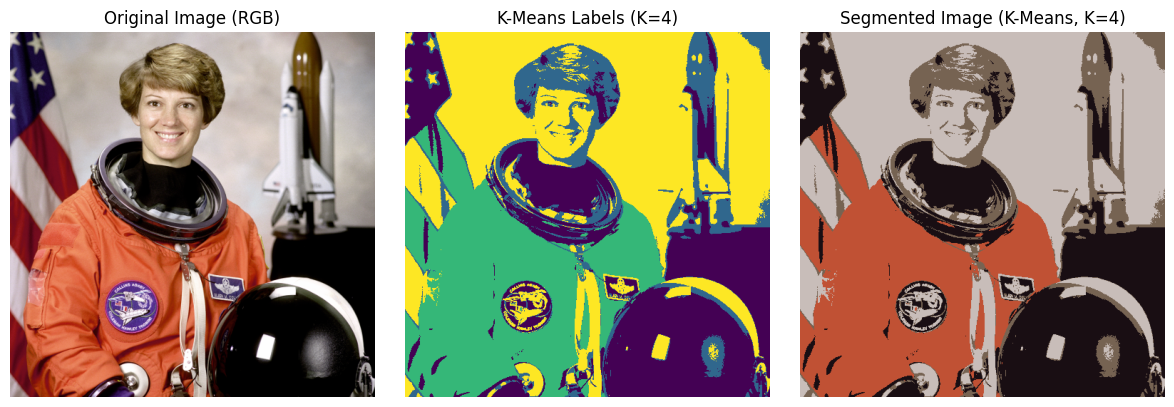

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data, io
from sklearn.cluster import KMeans
from skimage.color import rgb2lab, lab2rgb
import warnings

# 1. Memuat citra berwarna (contoh: astronaut)
image_astro = data.astronaut()

# Konversi ke float
image_astro_float = image_astro.astype(float) / 255.0

# 2. Konversi ke ruang warna Lab
image_lab = rgb2lab(image_astro_float)

rows, cols, dims = image_lab.shape
pixel_features = image_lab.reshape(rows * cols, dims)

# 3. Terapkan K-Means Clustering
n_clusters = 4

kmeans = KMeans(
    n_clusters=n_clusters,
    random_state=0,
    n_init=10
)

with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    pixel_labels = kmeans.fit_predict(pixel_features)

# 4. Reshape label kembali ke bentuk citra
segmented_labels = pixel_labels.reshape(rows, cols)

# 5. Buat citra hasil segmentasi
segmented_image_kmeans = np.zeros_like(image_lab)

centers_lab = kmeans.cluster_centers_

for k in range(n_clusters):

    cluster_pixels = (pixel_labels == k)

    mask_k = cluster_pixels.reshape(rows, cols)

    segmented_image_kmeans[mask_k] = centers_lab[k]

# Konversi kembali ke RGB
segmented_image_rgb = lab2rgb(segmented_image_kmeans)

# 6. Visualisasi Hasil
fig, axes = plt.subplots(ncols=3, figsize=(12, 4))
ax = axes.ravel()

ax[0].imshow(image_astro)
ax[0].set_title('Original Image (RGB)')
ax[0].axis('off')

ax[1].imshow(segmented_labels, cmap='viridis')
ax[1].set_title(f'K-Means Labels (K={n_clusters})')
ax[1].axis('off')

ax[2].imshow(segmented_image_rgb)
ax[2].set_title(f'Segmented Image (K-Means, K={n_clusters})')
ax[2].axis('off')

plt.tight_layout()
plt.show()

## **Praktikum 4 - Watershed Segmentation**

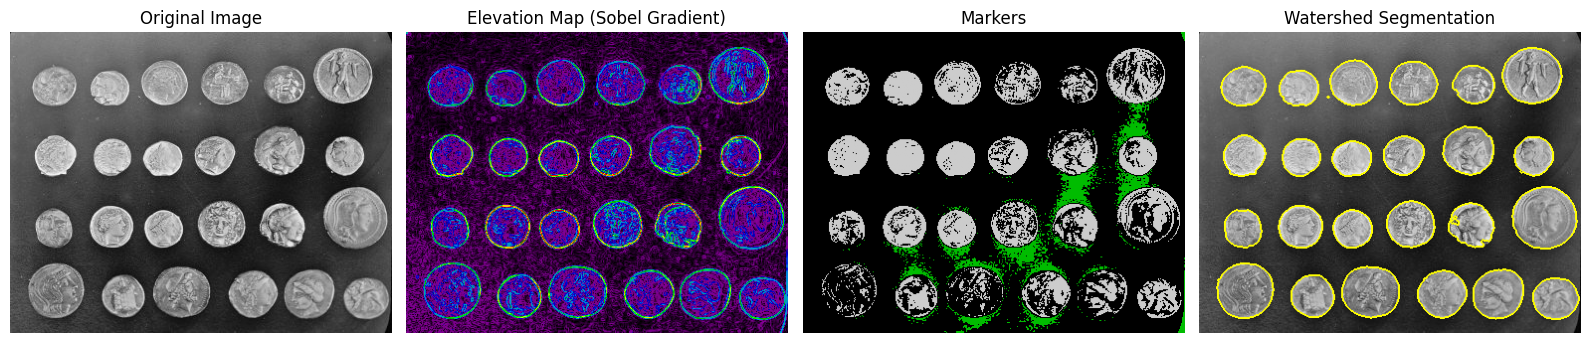

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data, filters, segmentation, morphology, measure
from scipy import ndimage as ndi

# 1. Memuat citra (contoh: coins)
image_coins = data.coins()

# 2. Hitung gradien citra
elevation_map = filters.sobel(image_coins)

# 3. Tentukan marker
markers = np.zeros_like(image_coins)

markers[image_coins < 30] = 1
markers[image_coins > 150] = 2

# Alternatif marker dari local maxima
# from skimage.feature import peak_local_max
# image_max = ndi.maximum_filter(image_coins, size=20, mode='constant')
# coordinates = peak_local_max(image_coins, min_distance=20)
# markers = np.zeros(image_coins.shape, dtype=bool)
# markers[tuple(coordinates.T)] = True
# markers = measure.label(markers)

# 4. Terapkan Watershed
segmentation_watershed = segmentation.watershed(
    elevation_map,
    markers
)

# Warnai hasil segmentasi
segmented_colored = segmentation.mark_boundaries(
    image_coins,
    segmentation_watershed
)

# 5. Visualisasi Hasil
fig, axes = plt.subplots(
    ncols=4,
    figsize=(16, 4),
    sharex=True,
    sharey=True
)

ax = axes.ravel()

ax[0].imshow(image_coins, cmap=plt.cm.gray)
ax[0].set_title('Original Image')
ax[0].axis('off')

ax[1].imshow(elevation_map, cmap=plt.cm.nipy_spectral)
ax[1].set_title('Elevation Map (Sobel Gradient)')
ax[1].axis('off')

ax[2].imshow(markers, cmap=plt.cm.nipy_spectral)
ax[2].set_title('Markers')
ax[2].axis('off')

ax[3].imshow(segmented_colored)
ax[3].set_title('Watershed Segmentation')
ax[3].axis('off')

plt.tight_layout()
plt.show()

## **Praktikum 5 - Perbandingan Visual Hasil Segmentasi**

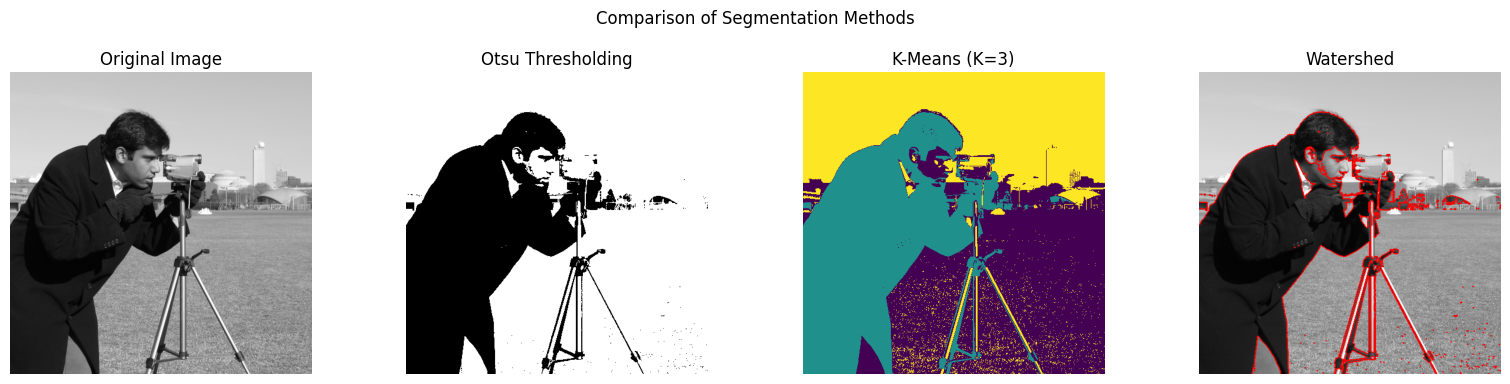

In [ ]:
import matplotlib.pyplot as plt
from skimage import data, filters, segmentation, img_as_float, color
from sklearn.cluster import KMeans
import numpy as np
import warnings

# 1. Pilih satu citra
image = data.camera()
image_float = img_as_float(image)

# 2. Segmentasi

# a) Otsu Thresholding
thresh_otsu = filters.threshold_otsu(image)
binary_otsu = image > thresh_otsu

# b) K-Means (K=3)
rows, cols = image.shape

pixel_features = image_float.reshape(rows * cols, 1)

n_clusters = 3

kmeans = KMeans(
    n_clusters=n_clusters,
    random_state=0,
    n_init=10
)

with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    pixel_labels = kmeans.fit_predict(pixel_features)

segmented_kmeans_labels = pixel_labels.reshape(rows, cols)

# c) Watershed
elevation_map = filters.sobel(image)

markers = np.zeros_like(image)

markers[image < thresh_otsu] = 1
markers[image > thresh_otsu] = 2

segmentation_watershed = segmentation.watershed(
    elevation_map,
    markers
)

# 3. Visualisasi Perbandingan
fig, axes = plt.subplots(
    1,
    4,
    figsize=(16, 4),
    sharex=True,
    sharey=True
)

ax = axes.ravel()

ax[0].imshow(image, cmap=plt.cm.gray)
ax[0].set_title('Original Image')
ax[0].axis('off')

ax[1].imshow(binary_otsu, cmap=plt.cm.gray)
ax[1].set_title('Otsu Thresholding')
ax[1].axis('off')

ax[2].imshow(segmented_kmeans_labels, cmap='viridis')
ax[2].set_title(f'K-Means (K={n_clusters})')
ax[2].axis('off')

# Watershed dengan batas merah
segmented_watershed_colored = segmentation.mark_boundaries(
    image_float,
    segmentation_watershed,
    color=(1, 0, 0)
)

ax[3].imshow(segmented_watershed_colored)
ax[3].set_title('Watershed')
ax[3].axis('off')

plt.suptitle('Comparison of Segmentation Methods')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])

plt.show()

## **Penugasan No. 3**

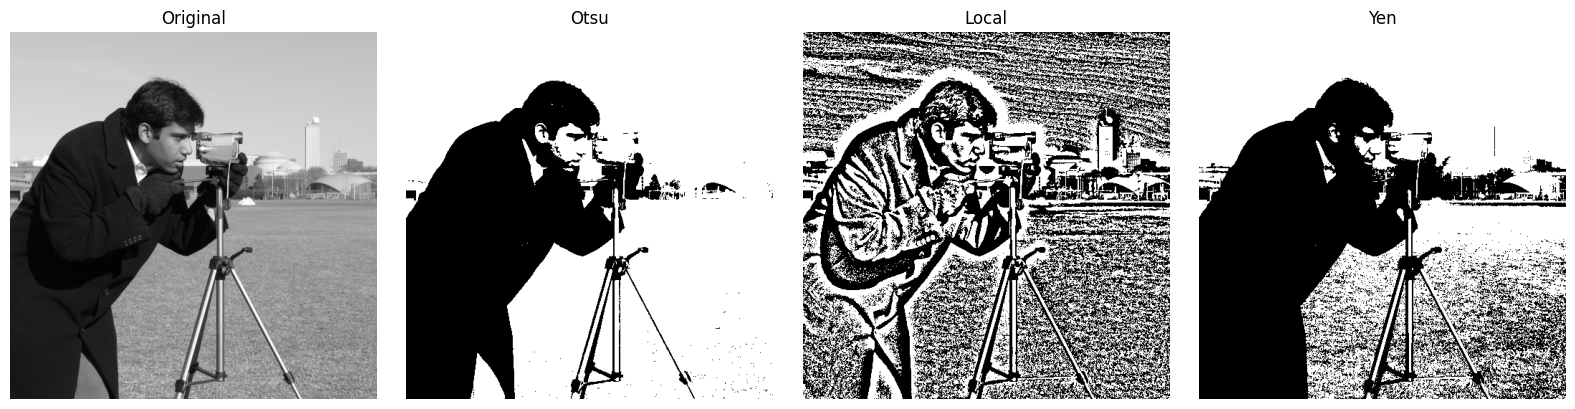

In [2]:
import matplotlib.pyplot as plt
from skimage import data, filters

# Memuat citra
image = data.camera()

# Threshold Otsu
thresh_otsu = filters.threshold_otsu(image)
binary_otsu = image > thresh_otsu

# Threshold Local
thresh_local = filters.threshold_local(image, block_size=35)
binary_local = image > thresh_local

# Threshold Yen
thresh_yen = filters.threshold_yen(image)
binary_yen = image > thresh_yen

# Visualisasi
fig, axes = plt.subplots(1,4, figsize=(16,4))

axes[0].imshow(image, cmap='gray')
axes[0].set_title('Original')

axes[1].imshow(binary_otsu, cmap='gray')
axes[1].set_title('Otsu')

axes[2].imshow(binary_local, cmap='gray')
axes[2].set_title('Local')

axes[3].imshow(binary_yen, cmap='gray')
axes[3].set_title('Yen')

for ax in axes:
    ax.axis('off')

plt.tight_layout()
plt.show()

## **Penugasan No. 4**

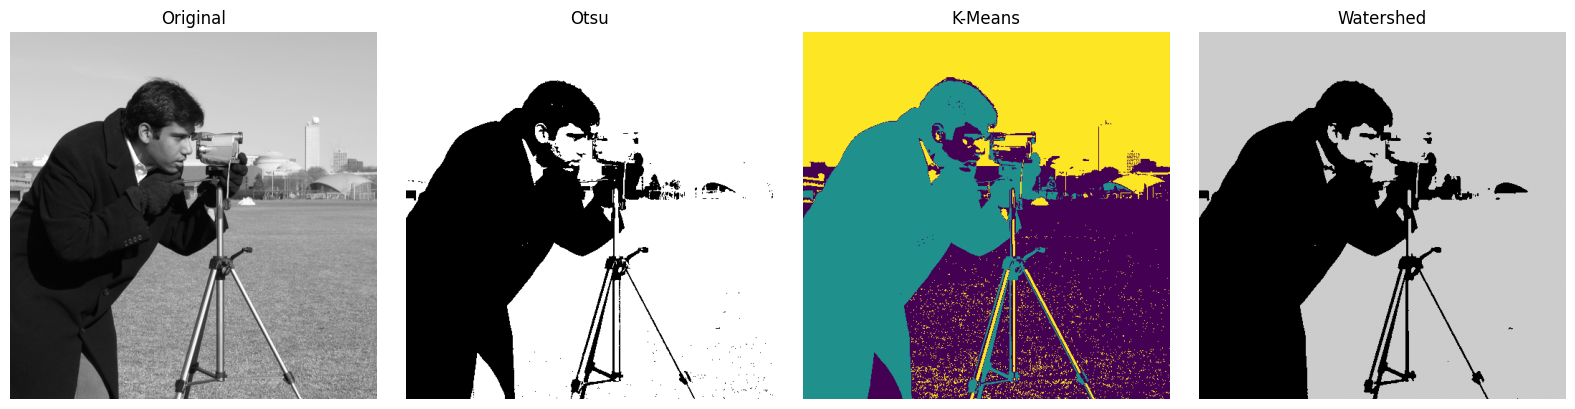

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data, filters, segmentation
from sklearn.cluster import KMeans

# Membaca citra
image = data.camera()

# Otsu Thresholding
thresh = filters.threshold_otsu(image)
binary_otsu = image > thresh

# K-Means
rows, cols = image.shape
pixel_values = image.reshape((-1, 1))

kmeans = KMeans(n_clusters=3, random_state=0, n_init=10)
labels = kmeans.fit_predict(pixel_values)

segmented_kmeans = labels.reshape(rows, cols)

# Watershed
gradient = filters.sobel(image)

markers = np.zeros_like(image)
markers[image < 80] = 1
markers[image > 150] = 2

watershed = segmentation.watershed(gradient, markers)

# Visualisasi
fig, axes = plt.subplots(1, 4, figsize=(16,4))

axes[0].imshow(image, cmap='gray')
axes[0].set_title('Original')

axes[1].imshow(binary_otsu, cmap='gray')
axes[1].set_title('Otsu')

axes[2].imshow(segmented_kmeans, cmap='viridis')
axes[2].set_title('K-Means')

axes[3].imshow(watershed, cmap='nipy_spectral')
axes[3].set_title('Watershed')

for ax in axes:
    ax.axis('off')

plt.tight_layout()
plt.show()